# Final Assignment
## 230X - High Frequency Finance

Daisy Niu

Hrafnhildur Jonsdottir

Paraj Goyal

Reza Zamani

Saurabh Baranwal

### a) Choose 2 equities and one FX pair

We continue with **NVDA** and **QRVO**, which we used in HW1 and HW2. They fit the assignment well because NVDA is highly liquid and QRVO is considerably less liquid. For the FX pair we use **EUR/USD**, the most actively traded currency pair.

### b) Choose a one-month period

We use **March 2025**, since we have complete data for all three securities in that month.

### c) Choose 2 trading signals from the paper plus our own signal

From the paper we use **Moving Average (MA)** and **Support and Resistance (SR)**. We chose SR over Channel Breakout (CB) because CB only trades when a channel exists, so SR generates more trades.

Our own signal is **mean reversion on a z-score**. Both paper signals are trend following, so this one takes the opposite side:

$$
z_t = \frac{m_t - \text{ma}_t(l, m)}{\text{std}_t(l, m)}
$$

where $m_t$ is the midpoint and $l$ is the lookback in intervals.

- **Short** if $z_t > k$
- **Long** if $z_t < -k$
- **Close** the position when $z_t$ crosses 0

In [2]:
import databento as db
import pandas as pd
from pathlib import Path

client = db.Historical("Your-API")
TZ = "America/New_York"
RAW = Path("data/raw"); RAW.mkdir(parents=True, exist_ok=True)

days = pd.bdate_range("2025-03-03", "2025-03-31")  # 21 trading days, no US holidays

SOURCES = {
    "equities": dict(dataset="XNAS.ITCH", symbols=["NVDA", "QRVO"], stype_in="raw_symbol"),
    "fx":       dict(dataset="GLBX.MDP3", symbols=["6E.v.0"],       stype_in="continuous"),
}

def window(day):
    lo = pd.Timestamp(f"{day.date()} 09:30", tz=TZ).tz_convert("UTC")
    hi = pd.Timestamp(f"{day.date()} 16:00", tz=TZ).tz_convert("UTC")
    return lo.isoformat(), hi.isoformat()

for name, src in SOURCES.items():
    cost = 0.0
    for d in days:
        lo, hi = window(d)
        cost += client.metadata.get_cost(schema="mbp-1", start=lo, end=hi, **src)
    print(name, "estimated cost: $", round(cost, 2))

BentoClientError: 401 auth_authentication_failed
Authentication failed.
documentation: https://databento.com/docs/portal/api-keys

***Download, one file per day***


In [3]:
KEEP = ["symbol", "action", "side", "price", "size",
        "bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00", "flags", "sequence"]

for name, src in SOURCES.items():
    for d in days:
        f = RAW / f"{name}_mbp1_{d.date()}.parquet"
        if f.exists():
            continue
        lo, hi = window(d)
        data = client.timeseries.get_range(schema="mbp-1", start=lo, end=hi, **src)
        df = data.to_df(price_type="float")[KEEP]
        if name == "fx":
            df["symbol"] = "EURUSD"
        df.index = df.index.tz_convert(TZ); df.index.name = "ts"
        df.to_parquet(f)
        print(name, d.date(), df.shape)

***Clean quotes and trades per symbol***

In [4]:
CLEAN = Path("data/clean"); CLEAN.mkdir(parents=True, exist_ok=True)

for sym, name in [("NVDA", "equities"), ("QRVO", "equities"), ("EURUSD", "fx")]:
    q_parts, t_parts = [], []
    for d in days:
        df = pd.read_parquet(RAW / f"{name}_mbp1_{d.date()}.parquet")
        df = df[df["symbol"] == sym]

        bbo = df[["bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00"]].copy()
        bbo.columns = ["bid", "ask", "bid_sz", "ask_sz"]
        bbo = bbo[bbo["ask"] > bbo["bid"]]
        bbo = bbo[bbo.ne(bbo.shift()).any(axis=1)]   # keep only rows where the touch changed
        bbo["mid"] = (bbo["bid"] + bbo["ask"]) / 2
        q_parts.append(bbo)

        t_parts.append(df.loc[df["action"] == "T", ["price", "size", "side"]])

    quotes, trades = pd.concat(q_parts), pd.concat(t_parts)
    quotes.to_parquet(CLEAN / f"quotes_{sym}_2025-03.parquet")
    trades.to_parquet(CLEAN / f"trades_{sym}_2025-03.parquet")
    print(sym, "| quote updates", len(quotes), "| trades", len(trades),
          "| median spread", round((quotes["ask"] - quotes["bid"]).median(), 5))

NVDA | quote updates 103115808 | trades 9537782 | median spread 0.01
QRVO | quote updates 755237 | trades 211859 | median spread 0.05
EURUSD | quote updates 13097861 | trades 525445 | median spread 5e-05


***Tick frequency per asset***

How often the book changes sets how much can happen during an execution delay. *Mid changes per 100 ms* is the expected number of price moves a 100 ms delay misses. Saved to `tick_frequency.csv`.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

CLEAN = Path("data/clean")
SYMBOLS = ["NVDA", "QRVO", "EURUSD"]
SESSION_S = 6.5 * 3600  # 09:30-16:00

rows = []
for sym in SYMBOLS:
    q = pd.read_parquet(CLEAN / f"quotes_{sym}_2025-03.parquet", columns=["bid", "ask", "mid"])
    t = pd.read_parquet(CLEAN / f"trades_{sym}_2025-03.parquet", columns=["size"])
    day = q.index.normalize()
    new_day = np.r_[True, day[1:] != day[:-1]]   # first update of each day has no predecessor
    n_days = new_day.sum()
    gap_ms = np.diff(q.index.asi8, prepend=q.index.asi8[0])[~new_day] / 1e6
    mid_moves = (q["mid"].diff().ne(0).to_numpy() & ~new_day).sum()
    spread = q["ask"] - q["bid"]
    rows.append({
        "symbol": sym,
        "quote updates / day": len(q) / n_days,
        "quote updates / s": len(q) / n_days / SESSION_S,
        "mid changes / s": mid_moves / n_days / SESSION_S,
        "mid changes per 100 ms": mid_moves / n_days / SESSION_S * 0.1,
        "trades / day": len(t) / n_days,
        "median ms between updates": np.median(gap_ms),
        "% updates < 100 ms apart": (gap_ms < 100).mean() * 100,
        "median spread ($)": spread.median(),
        "median spread (bps)": (spread / q["mid"] * 1e4).median(),
    })

tick = pd.DataFrame(rows).set_index("symbol")
tick.to_csv("tick_frequency.csv")
fmt = lambda x: f"{x:,.0f}" if abs(x) >= 100 else f"{x:,.2f}" if abs(x) >= 1 else f"{x:.3g}"
print(tick.T.to_string(float_format=fmt))

symbol                         NVDA   QRVO  EURUSD
quote updates / day       4,910,277 35,964 623,708
quote updates / s               210   1.54   26.65
mid changes / s               22.56  0.514    1.61
mid changes per 100 ms         2.26 0.0514   0.161
trades / day                454,180 10,089  25,021
median ms between updates    0.0527   0.36    0.12
% updates < 100 ms apart      99.19  75.70   93.28
median spread ($)              0.01   0.05   5e-05
median spread (bps)           0.905   7.11   0.461


# Implement the strategy

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

CLEAN = Path("data/clean")
SYMBOLS = ["NVDA", "QRVO", "EURUSD"]
WINDOW = pd.Timedelta("2s")
DELAYS = {"0ms": pd.Timedelta(0), "100ms": pd.Timedelta("100ms"), "1s": pd.Timedelta("1s")}
CALIB_END = "2025-03-07" # first week sets depth and k, then both stay fixed
Q = 0.95 # "strong" = top 5% of |OFI| in the first week

def day_ofi(d):
    """Rolling 2s order flow imbalance for one day, exact in event time."""
    pb, pa = d["bid"].to_numpy(), d["ask"].to_numpy()
    sb, sa = d["bid_sz"].to_numpy(float), d["ask_sz"].to_numpy(float)
    # buyers gain: bid up (+new size), same bid (+size change), bid down (-old size)
    e_bid = np.where(pb[1:] > pb[:-1], sb[1:], np.where(pb[1:] == pb[:-1], sb[1:] - sb[:-1], -sb[:-1]))
    # sellers gain: ask down (+new size), same ask (+size change), ask up (-old size)
    e_ask = np.where(pa[1:] < pa[:-1], sa[1:], np.where(pa[1:] == pa[:-1], sa[1:] - sa[:-1], -sa[:-1]))
    e, t = e_bid - e_ask, d.index[1:]
    # each update adds its pressure at t and removes it again at t + 2s
    ev = pd.concat([pd.Series(e, index=t), pd.Series(-e, index=t + WINDOW)])
    return ev.groupby(level=0).sum().sort_index().cumsum()

def positions(x, k):
    """+1 after x > k until x <= 0, -1 after x < -k until x >= 0, else flat."""
    lng = pd.Series(np.where(x > k, 1.0, np.where(x <= 0, 0.0, np.nan)), index=x.index).ffill().fillna(0.0)
    sht = pd.Series(np.where(x < -k, 1.0, np.where(x >= 0, 0.0, np.nan)), index=x.index).ffill().fillna(0.0)
    pos = lng - sht
    pos.iloc[-1] = 0.0 # always flat at the end of the day
    return pos

def run_day(d, pos, delay):
    dpos = pos.diff().fillna(pos.iloc[0])
    tr = dpos[dpos != 0]
    orders = pd.DataFrame({"ts": tr.index + delay, "qty": tr.to_numpy()})
    quotes = d[["bid", "ask", "mid"]].rename_axis("ts").reset_index()
    f = pd.merge_asof(orders, quotes, on="ts", direction="backward")
    px = np.where(f["qty"] > 0, f["ask"], f["bid"])
    ref = d["mid"].mean()
    return {"ret_bps": -(f["qty"] * px).sum() / ref * 1e4,
            "ret_mid_bps": -(f["qty"] * f["mid"]).sum() / ref * 1e4,
            "trades": len(f)}

rows = []
for sym in SYMBOLS:
    q = pd.read_parquet(CLEAN / f"quotes_{sym}_2025-03.parquet")
    days = {day: d for day, d in q.groupby(q.index.date)}
    ofi = {day: day_ofi(d) for day, d in days.items()}
    calib = [day for day in days if str(day) <= CALIB_END]
    depth = np.mean([((days[c]["bid_sz"] + days[c]["ask_sz"]) / 2).mean() for c in calib])
    k = pd.concat([ofi[c] / depth for c in calib]).abs().quantile(Q)
    print(sym, "| typical depth", round(depth, 1), "| k", round(k, 3))
    for day, d in days.items():
        if day in calib:
            continue
        pos = positions(ofi[day] / depth, k)
        for name, delay in DELAYS.items():
            rows.append({"symbol": sym, "day": day, "delay": name, **run_day(d, pos, delay)})

res = pd.DataFrame(rows)
res.to_csv("ofi_delay_results.csv", index=False)

summary = res.groupby(["symbol", "delay"])[["ret_bps", "ret_mid_bps", "trades"]].mean().unstack("delay")
summary = summary.reindex(columns=list(DELAYS), level=1).reindex(SYMBOLS)
print(summary.round(2))

for col in ["ret_bps", "ret_mid_bps"]:
    s = summary[col]
    print("\ncost of delay,", col, "(bps per day)")
    print(pd.DataFrame({"100ms": s["0ms"] - s["100ms"], "1s": s["0ms"] - s["1s"]}).round(2))

NVDA | typical depth 722.6 | k 18.641
QRVO | typical depth 163.5 | k 9.798
EURUSD | typical depth 20.5 | k 9.491
       ret_bps                 ret_mid_bps                 trades           \
delay      0ms   100ms      1s         0ms  100ms     1s      0ms    100ms   
symbol                                                                       
NVDA   -609.21 -924.53 -948.50      351.75 -40.84 -59.71  1530.88  1530.88   
QRVO   -451.44 -517.78 -554.97      110.49  57.74  29.02   160.25   160.25   
EURUSD -181.09 -191.76 -188.31        7.14  -1.52   2.48   633.94   633.94   

                 
delay        1s  
symbol           
NVDA    1530.88  
QRVO     160.25  
EURUSD   633.94  

cost of delay, ret_bps (bps per day)
         100ms      1s
symbol                
NVDA    315.32  339.29
QRVO     66.34  103.53
EURUSD   10.68    7.22

cost of delay, ret_mid_bps (bps per day)
         100ms      1s
symbol                
NVDA    392.59  411.46
QRVO     52.75   81.47
EURUSD    8.65    4.66


Before the spread: average daily return, filled at the mid


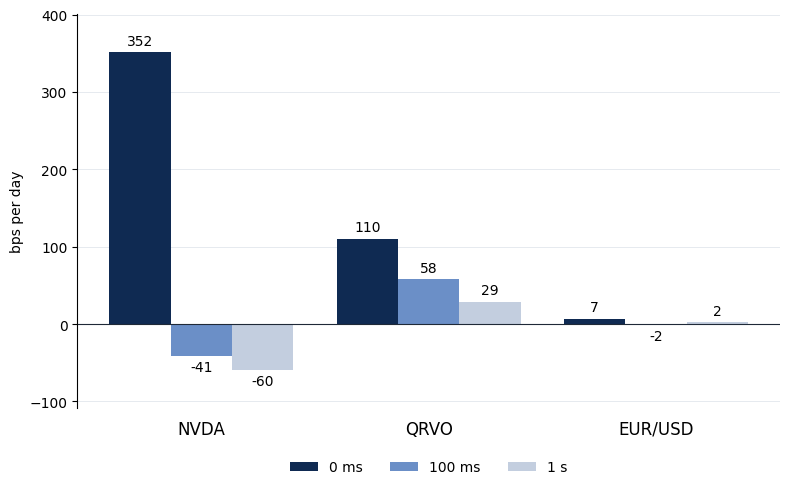

After the spread: average daily return, buy at ask and sell at bid


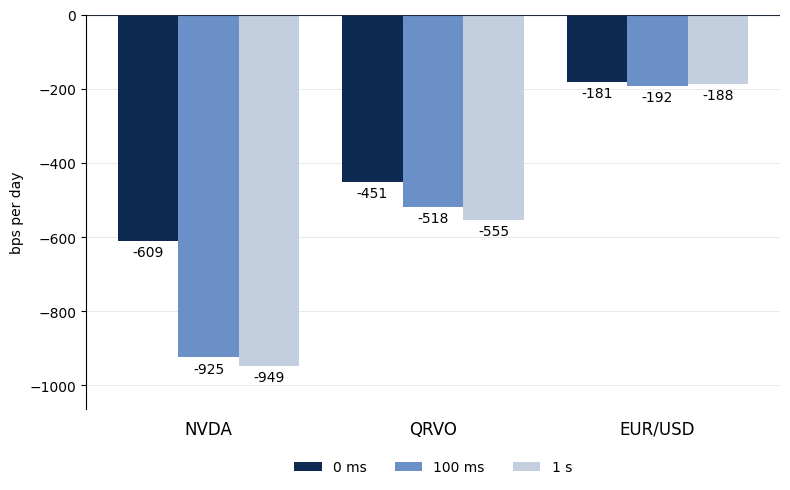

        100 ms    1 s
symbol               
NVDA     315.0  339.0
QRVO      66.0  104.0
EURUSD    11.0    7.0


In [4]:
import matplotlib.pyplot as plt

res = pd.read_csv("ofi_delay_results.csv")
SYMBOLS = ["NVDA", "QRVO", "EURUSD"]
DELAYS = ["0ms", "100ms", "1s"]
LABELS = {"0ms": "0 ms", "100ms": "100 ms", "1s": "1 s"}
COLORS = {"0ms": "#0F2A52", "100ms": "#6B8FC7", "1s": "#C3CEDF"}

def delay_chart(col, title, fname):
    avg = res.groupby(["symbol", "delay"])[col].mean().unstack("delay").loc[SYMBOLS, DELAYS]
    fig, ax = plt.subplots(figsize=(8, 5))
    width = 0.27
    print(title)
    for i, dly in enumerate(DELAYS):
        x = [j + (i - 1) * width for j in range(len(SYMBOLS))]
        bars = ax.bar(x, avg[dly], width, label=LABELS[dly], color=COLORS[dly])
        ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=10)
    ax.axhline(0, color="#1F2937", linewidth=0.8)
    ax.set_xticks(range(len(SYMBOLS)))
    ax.set_xticklabels(["NVDA", "QRVO", "EUR/USD"], fontsize=12)
    ax.tick_params(axis="x", length=0, pad=8)
    ax.set_ylabel("bps per day")
    ax.grid(axis="y", color="#E2E6EC", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.margins(y=0.12)
    ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
    fig.tight_layout()
    fig.savefig(fname, dpi=200)
    plt.show()
    return avg

before = delay_chart("ret_mid_bps", "Before the spread: average daily return, filled at the mid",
                     "delay_before_spread.png")

after = delay_chart("ret_bps", "After the spread: average daily return, buy at ask and sell at bid",
                    "delay_after_spread.png")

cost = pd.DataFrame({"100 ms": after["0ms"] - after["100ms"], "1 s": after["0ms"] - after["1s"]})
print(cost.round(0))

# Backtest engine

`backtest(quotes, pos, delay)` takes any signal as a target position in {-1, 0, +1} indexed by the time the signal fires, and fills each change at the quote in effect at signal time + delay. Buys pay the ask and sells receive the bid (`fill="touch"`), or both fill at the mid (`fill="mid"`) to show returns before the spread. The whole $1,000,000 book goes into every entry, so returns compound, and the position is closed at the last quote of each day.

EUR/USD is the CME 6E future (125,000 EUR per contract); positions are sized in fractional contracts, so returns do not depend on the multiplier.

**To add a signal:** build `pos` for each symbol, call `backtest` for each delay and fill, and append rows to `results` with your signal name.

In [5]:
CAPITAL = 1_000_000
TZ = "America/New_York"

def backtest(quotes, pos, delay, capital=CAPITAL, fill="touch", mult=1.0):
    """Run any signal through delayed execution on a $1M book.

    quotes: clean quotes for the month (bid, ask, mid), indexed by ts
    pos:    target position in {-1, 0, +1}, indexed by the time the signal fires
    delay:  pd.Timedelta, each order fills at the quote in effect at signal time + delay
    fill:   "touch" buys at the ask and sells at the bid, "mid" fills at the mid
    mult:   contract multiplier (125,000 EUR for 6E futures, 1 for shares)

    The whole book goes into every entry (so returns compound), and the
    strategy is closed at the last quote of each day.
    Returns (summary dict, round trips, end-of-day book value).
    """
    # orders = every change in target position, plus a forced close at each day's last quote
    orders = []
    for day, p in pos.astype(float).groupby(pos.index.date):
        close = pd.Timestamp(f"{day} 16:00", tz=TZ)
        last_quote = quotes.index[quotes.index.searchsorted(close, side="right") - 1]
        p = pd.concat([p, pd.Series([0.0], index=[max(last_quote, p.index[-1])])])
        p = p[~p.index.duplicated(keep="last")]
        orders.append(p[p.ne(p.shift(fill_value=0.0))])
    orders = pd.concat(orders)

    fill_ts = orders.index + delay
    i = quotes.index.searchsorted(fill_ts, side="right") - 1   # last quote at or before fill time
    bid, ask, mid = (quotes[c].to_numpy()[i] for c in ("bid", "ask", "mid"))
    buy_px, sell_px = (mid, mid) if fill == "mid" else (ask, bid)

    cash, units, held, trips = float(capital), 0.0, 0, []
    for j, target in enumerate(orders.to_numpy()):
        if held != 0:   # close the open position
            px = sell_px[j] if held > 0 else buy_px[j]
            cash += units * px * mult
            trips.append((entry_ts, fill_ts[j], held, entry_px, px, units * (px - entry_px) * mult))
            units, held = 0.0, 0
        if target != 0:   # open a new one with the whole book
            px = buy_px[j] if target > 0 else sell_px[j]
            units = target * cash / (px * mult)
            cash -= units * px * mult
            held, entry_ts, entry_px = int(target), fill_ts[j], px

    trips = pd.DataFrame(trips, columns=["entry_ts", "exit_ts", "side", "entry_px", "exit_px", "pnl"])
    daily = trips.groupby(trips["exit_ts"].dt.date)["pnl"].sum()
    value = capital + daily.cumsum()
    final = value.iloc[-1] if len(value) else capital
    summary = {
        "final_value": final,
        "total_ret_pct": (final / capital - 1) * 100,
        "round_trips": len(trips),
        "hit_rate_pct": (trips["pnl"] > 0).mean() * 100,
        "avg_hold_s": (trips["exit_ts"] - trips["entry_ts"]).dt.total_seconds().mean(),
        "days": len(value),
    }
    return summary, trips, value

***OFI through the engine***

Same OFI positions as above (threshold calibrated on Mar 3-7, results on the remaining 16 days). Cost of delay (Figure 6 in the paper) is the drop in total return relative to 0 ms, in percentage points. NVDA takes about 6 minutes and 9 GB of memory.

In [6]:
DELAY = {"0ms": pd.Timedelta(0), "100ms": pd.Timedelta("100ms"), "1s": pd.Timedelta("1s")}
MULT = {"NVDA": 1, "QRVO": 1, "EURUSD": 125_000}

def ofi_positions(q):
    """OFI target positions for the out-of-sample days (uses day_ofi and positions from above)."""
    days = {day: d for day, d in q.groupby(q.index.date)}
    calib = [day for day in days if str(day) <= CALIB_END]
    ofi = {day: day_ofi(d) for day, d in days.items()}
    depth = np.mean([((days[c]["bid_sz"] + days[c]["ask_sz"]) / 2).mean() for c in calib])
    k = pd.concat([ofi[c] / depth for c in calib]).abs().quantile(Q)
    return pd.concat([positions(ofi[day] / depth, k) for day in days if day not in calib])

results, values = [], {}
for sym in SYMBOLS:
    q = pd.read_parquet(CLEAN / f"quotes_{sym}_2025-03.parquet")
    pos = ofi_positions(q)
    for dname, delay in DELAY.items():
        for fill in ["touch", "mid"]:
            s, trips, value = backtest(q, pos, delay, fill=fill, mult=MULT[sym])
            results.append({"signal": "OFI", "symbol": sym, "delay": dname, "fill": fill, **s})
            values["OFI", sym, dname, fill] = value
    del q

results = pd.DataFrame(results)
results.to_csv("backtest_results.csv", index=False)
print(results.round(2).to_string(index=False))

# cost of delay (Figure 6): drop in total return vs. 0 ms, in percentage points
ret = results.pivot_table(index=["signal", "symbol", "fill"], columns="delay", values="total_ret_pct")
cost_of_delay = pd.DataFrame({"100ms": ret["0ms"] - ret["100ms"], "1s": ret["0ms"] - ret["1s"]})
print("\ncost of delay (percentage points of total return)")
print(cost_of_delay.round(2))

signal symbol delay  fill  final_value  total_ret_pct  round_trips  hit_rate_pct  avg_hold_s  days
   OFI   NVDA   0ms touch    377255.47         -62.27        12283         27.09        2.38    16
   OFI   NVDA   0ms   mid   1754560.97          75.46        12283         44.64        2.38    16
   OFI   NVDA 100ms touch    227745.02         -77.23        12283         22.20        2.38    16
   OFI   NVDA 100ms   mid    936135.96          -6.39        12283         36.56        2.38    16
   OFI   NVDA    1s touch    219188.77         -78.08        12283         23.13        2.38    16
   OFI   NVDA    1s   mid    908418.32          -9.16        12283         39.82        2.38    16
   OFI   QRVO   0ms touch    486063.35         -51.39         1288          7.92        2.33    16
   OFI   QRVO   0ms   mid   1193717.25          19.37         1288         50.08        2.33    16
   OFI   QRVO 100ms touch    437013.01         -56.30         1288          4.50        2.33    16
   OFI   Q

## Order Flow Imbalance

In [7]:
res = pd.read_csv("ofi_delay_results.csv", parse_dates=["day"])

# realized volatility per day from 1-minute midpoint returns
rows = []
for sym in SYMBOLS:
    mid = pd.read_parquet(CLEAN / f"quotes_{sym}_2025-03.parquet", columns=["mid"])["mid"]
    for day, x in mid.groupby(mid.index.date):
        r = np.log(x.resample("1min").last().dropna()).diff().dropna()
        rows.append({"symbol": sym, "day": pd.Timestamp(day), "rv_bps": np.sqrt((r ** 2).sum()) * 1e4})
rv = pd.DataFrame(rows)

wide = res.pivot_table(index=["symbol", "day"], columns="delay", values="ret_mid_bps").reset_index()
wide["cost_100ms"] = wide["0ms"] - wide["100ms"]
wide["cost_1s"] = wide["0ms"] - wide["1s"]
wide = wide.merge(rv, on=["symbol", "day"])
wide["regime"] = np.where(wide["rv_bps"] > wide.groupby("symbol")["rv_bps"].transform("median"),
                          "high vol", "low vol")

print(wide.groupby(["symbol", "regime"])[["rv_bps", "0ms", "cost_100ms", "cost_1s"]].mean().round(1))

                 rv_bps    0ms  cost_100ms  cost_1s
symbol regime                                      
EURUSD high vol    31.7    9.6         9.7      7.7
       low vol     25.5    4.7         7.6      1.6
NVDA   high vol   318.1  394.0       484.0    505.8
       low vol    197.6  309.5       301.1    317.2
QRVO   high vol   228.1  157.9        69.4    109.3
       low vol    172.0   63.1        36.1     53.6


# Support and Resistance Signal

In [9]:
SR_INTERVALS = ["30s", "1s"] 
SR_N        = 60
SR_BAND     = 0.0
SR_START    = "2025-03-10"

DELAY = {"0ms": pd.Timedelta(0), "100ms": pd.Timedelta("100ms"), "1s": pd.Timedelta("1s")}
MULT  = {"NVDA": 1, "QRVO": 1, "EURUSD": 125_000}
SYMBOLS = ["NVDA", "QRVO", "EURUSD"]

def day_slices(index):
    """(day, start, stop) row ranges per trading day, without building a date per row."""
    days = pd.date_range(index[0].normalize(), index[-1].normalize(), freq="D")
    edges = index.searchsorted(days.append(days[-1:] + pd.Timedelta("1D")))
    return [(d, a, b) for d, a, b in zip(days, edges[:-1], edges[1:]) if b > a]

def sr_positions(q, interval="30s", n=SR_N, band=SR_BAND, start=SR_START):
    """SR target positions in {-1, 0, +1}, stamped with the clock time the signal fires.

    Follows equation (7) of Scholtus and van Dijk (2012). The mid is sampled on a fixed
    clock. Resistance / support are the highest / lowest mid over the previous n intervals,
    counting the highs and lows reached inside each interval (current interval excluded).
    Long when the mid breaks above resistance, short when it breaks below support,
    otherwise the previous position is kept. Flat at the start of each day.
    """
    mid_all, out = q["mid"].to_numpy(), []
    for day, a, b in day_slices(q.index):
        if day < pd.Timestamp(start, tz=day.tz):
            continue
        ts, mid = q.index[a:b], mid_all[a:b]
        grid = pd.date_range(day + pd.Timedelta("9h30min"), day + pd.Timedelta("16h"), freq=interval)
        c = ts.searchsorted(grid, side="right")
        p = np.where(c > 0, mid[np.maximum(c - 1, 0)], np.nan)

        hi, lo = p.copy(), p.copy()
        hi[1:], lo[1:] = np.fmax(p[1:], p[:-1]), np.fmin(p[1:], p[:-1])
        k = np.flatnonzero(np.diff(c) > 0) + 1          
        if len(k):
            starts = c[k - 1]
            mx = np.maximum.reduceat(mid, starts)
            mn = np.minimum.reduceat(mid, starts)

            last = slice(starts[-1], c[k[-1]])
            mx[-1], mn[-1] = mid[last].max(), mid[last].min()
            hi[k], lo[k] = np.fmax(hi[k], mx), np.fmin(lo[k], mn)
        p = pd.Series(p, index=grid)
        res = pd.Series(hi, index=grid).rolling(n).max().shift(1)
        sup = pd.Series(lo, index=grid).rolling(n).min().shift(1)
        sig = pd.Series(np.where(p > res * (1 + band), 1.0, np.where(p < sup * (1 - band), -1.0, np.nan)),
                        index=grid)
        pos = sig.ffill().fillna(0.0)
        out.append(pos[pos.ne(pos.shift(fill_value=0.0))]) 
    return pd.concat(out)

sr_rows, sr_daily = [], []
for sym in SYMBOLS:
    q = pd.read_parquet(CLEAN / f"quotes_{sym}_2025-03.parquet", columns=["bid", "ask", "mid"])
    for interval in SR_INTERVALS:
        pos = sr_positions(q, interval=interval)
        for dname, delay in DELAY.items():
            for fill in ["touch", "mid"]:
                s, trips, value = backtest(q, pos, delay, fill=fill, mult=MULT[sym])
                sr_rows.append({"signal": "SR", "interval": interval, "symbol": sym,
                                "delay": dname, "fill": fill, **s})
                prev = value.shift(fill_value=CAPITAL)
                sr_daily.append(pd.DataFrame({"interval": interval, "symbol": sym, "delay": dname, "fill": fill,
                                              "day": value.index,
                                              "ret_bps": ((value - prev) / prev * 1e4).to_numpy()}))
    del q

sr_results = pd.DataFrame(sr_rows)
sr_results.to_csv("sr_results.csv", index=False)
pd.concat(sr_daily).to_csv("sr_daily_results.csv", index=False)
print(sr_results.round(2).to_string(index=False))

ret = sr_results.pivot_table(index=["interval", "symbol", "fill"], columns="delay", values="total_ret_pct")
sr_cost = pd.DataFrame({"100ms": ret["0ms"] - ret["100ms"], "1s": ret["0ms"] - ret["1s"]})
print("\nSR cost of delay (percentage points of total return)")
print(sr_cost.round(2))

signal interval symbol delay  fill  final_value  total_ret_pct  round_trips  hit_rate_pct  avg_hold_s  days
    SR      30s   NVDA   0ms touch    964299.24          -3.57          104         36.54     3164.71    16
    SR      30s   NVDA   0ms   mid    975802.61          -2.42          104         38.46     3164.71    16
    SR      30s   NVDA 100ms touch    963785.75          -3.62          104         37.50     3164.71    16
    SR      30s   NVDA 100ms   mid    974829.06          -2.52          104         38.46     3164.71    16
    SR      30s   NVDA    1s touch    965412.07          -3.46          104         37.50     3164.71    16
    SR      30s   NVDA    1s   mid    976944.57          -2.31          104         37.50     3164.71    16
    SR       1s   NVDA   0ms touch    571053.67         -42.89         3276         31.62      113.88    16
    SR       1s   NVDA   0ms   mid    818396.14         -18.16         3276         33.94      113.88    16
    SR       1s   NVDA 100ms